#Notebook: KNN
**Autora:** Yadsiri Vazquez\
**Materia:** Clasificación inteligente de datos  

---
##1.1  Fundamentos de la técnica

El algoritmo k-Nearest Neighbors (kNN) es una técnica de clasificación supervisada basada en la similitud entre muestras.
Su principio básico consiste en clasificar un nuevo punto de datos según la mayoría de las clases presentes entre sus "k" vecinos más cercanos, medidos por una métrica de distancia (por defecto es la euclidiana).

K = con cuantos K-Vecinos voy a comparar el K (punto base)

Ventajas:
- Simple de entender e implementar.
- No requiere un modelo paramétrico.

Desventajas:
- Costoso en tiempo de predicción (debe calcular distancias a todos los puntos).
- Sensible a la escala de los datos y al valor de *k* elegido.


##1.2  Modelo Matemático
Primero se cuenta con un conjunto de datos de entrenamiento, es decir, un grupo de ejemplos que ya tienen una etiqueta o clase asignada. Cada ejemplo posee varias características (por ejemplo, el largo y ancho de los pétalos y sépalos en el conjunto de datos de flores Iris).

Cuando llega un nuevo dato sin clasificar, el algoritmo realiza los siguientes pasos:

1.- Calcula la distancia entre este nuevo dato y todos los datos del conjunto de entrenamiento. Generalmente se utiliza la distancia euclidiana, que mide qué tan “lejos” o “cerca” está un punto de otro en el espacio de características.

d(X₁, X₂) = √(Y₂ - X₁)² + (Y₂ - Y₁)²

Donde:
- X₁=(X₁,Y₁) es el nuevo punto a clasificar.
- X₂=(X₂,Y₂) es un punto del conjunto de entrenamiento.


2.- Selecciona los k vecinos más cercanos, es decir, los k puntos del conjunto de entrenamiento que se encuentran más próximos al nuevo dato.

3.- Asigna la clase que más se repite entre esos k vecinos. Por eso se dice que KNN clasifica “por mayoría de votos” entre los vecinos más cercanos


##1.3  Descripción de la librería, clases, funciones en su respectiva sección

Librerías utilizadas:

1. Numpy: Para manejo de arreglos numéricos.
2. Pandas: En este tutorial, se usa para crear un DataFrame con las características del dataset Iris y agregar la columna de la clase o etiqueta de cada flor
3. Matplotlib (matplotlib.pyplot) librería para la creación de gráficos en 2D.  Aquí se utiliza para mostrar gráficamente la distribución de las características del dataset y los resultados del modelo.
4. Seaborn (seaborn) Está construida sobre Matplotlib y proporciona  gráficos estadísticos mas visuales.
5. Scikit-learn (sklearn): Proporciona herramientas para realizar tareas de clasificación, regresión, clustering, reducción de dimensionalidad, entre otras.

Clases Y funciones utilizadas:

1. load_iris

sklearn.datasets: su función consiste en que carga el dataset Iris, un conjunto de datos clásico que contiene 150 muestras de tres especies de flores: setosa, versicolor y virginica. Cuya *salida* es una matriz con las 4 características de cada flor (longitud y ancho de sépalos y pétalos). Su *target*: vector con las etiquetas (0, 1 o 2).

2. train_test_split

sklearn.model_selection: Divide el dataset en dos subconjuntos:

- Conjunto de entrenamiento: para ajustar el modelo.
- Conjunto de prueba: para evaluar su desempeño.

3. StandardScaler

sklearn.preprocessing: Normaliza los datos para que cada característica tenga media 0 y desviación estándar 1.
- fit_transform(X_train): calcula los parámetros de normalización y aplica la transformación al conjunto de entrenamiento.
- transform(X_test): aplica la misma escala al conjunto de prueba.


4. KNeighborsClassifier

sklearn.neighbors: Implementa el algoritmo de clasificación k-Nearest Neighbors.

5. confusion_matrix y accuracy_score

sklearn.metrics: Evalúan el rendimiento del modelo.

- confusion_matrix(y_test, y_pred): muestra el número de aciertos y errores por clase.

- accuracy_score(y_test, y_pred): devuelve la proporción de predicciones correctas (precisión global del modelo).

['setosa' 'versicolor' 'virginica']
Resumen estadistico del dataset:

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


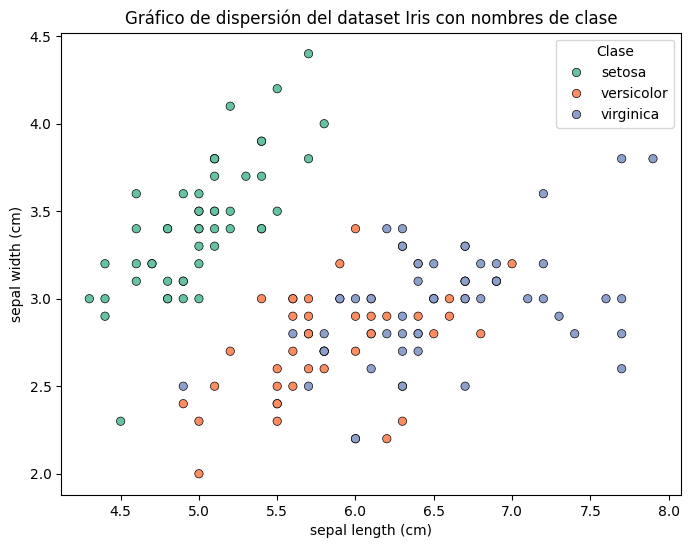

In [1]:
# 1.4.1 Preprocesamiento

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# dataset
iris = load_iris()
X = iris.data #Caracteristicas numericas
y = iris.target #Etiquetas


df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
print(iris.target_names)

print("Resumen estadistico del dataset:\n")
print(df.describe())

df['clase'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})


plt.figure(figsize=(8,6))
sns.scatterplot( data=df, x=iris.feature_names[0], y=iris.feature_names[1], hue='clase', palette='Set2', edgecolor='k')
plt.title('Gráfico de dispersión del dataset Iris con nombres de clase')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend(title='Clase')
plt.show()

###1.4.2 Feature Engineering
En esta etapa se seleccionan las variables más relevantes para el modelo.
En el dataset Iris, las cuatro variables son importantes, por lo que se usarán todas:
- Sepal length
- Sepal width
- Petal length
- Petal width

In [2]:
#Se separan los datos de entrenamiento con los de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#Normalizamos las características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Entrenamiento del modelo

In [3]:
from sklearn.neighbors import KNeighborsClassifier #clasifica un punto nuevo comparándolo con sus k vecinos más cercanos en el conjunto de entrenamiento

#crearlo
k = 5
knn = KNeighborsClassifier(n_neighbors=k)

#Entrenamiento, se guardan los datos
knn.fit(X_train, y_train)

print(f"Modelo KNN entrenado con k = {k}")

Modelo KNN entrenado con k = 5


In [4]:
# 1.4.3 Prediction

#función que clasifica un nuevo patrón
def clasificar_patron(nuevo_patron):
    """
    Clasifica un nuevo patrón usando el modelo entrenado.
    """
    nuevo_patron = scaler.transform([nuevo_patron])
    prediccion = knn.predict(nuevo_patron)
    clase = iris.target_names[prediccion[0]]
    print(f"El patrón pertenece a la clase: {clase}")

#Ejemplo: predecir una nueva flor
nuevo_patron = [5.1, 3.5, 1.4, 0.2]
clasificar_patron(nuevo_patron)

El patrón pertenece a la clase: setosa


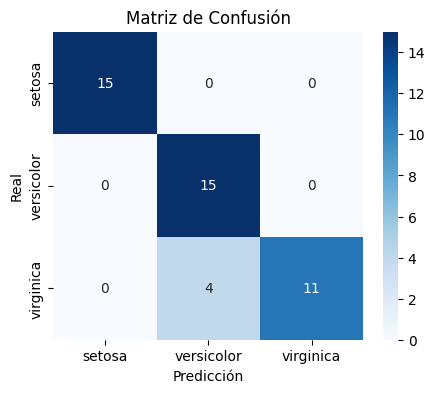


Precisión del modelo (Accuracy): 0.9111


In [5]:
# 1.4.4 Model Evaluation

from sklearn.metrics import confusion_matrix, accuracy_score

#Predicciones sobre el conjunto de prueba
y_pred = knn.predict(X_test)

#Matriz de confusión y exactitud
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

print(f"\nPrecisión del modelo (Accuracy): {round(acc, 4)}")

La matriz de confusión es una tabla que permite visualizar el rendimiento del algoritmo de clasificación. Cada fila de la matriz representa las instancias en una clase Real, mientras que cada columna representa las instancias en una clase Predicha.

Valores en la Diagonal Principal (15,15,11): Indican el número de predicciones correctas (Verdaderos Positivos) para cada una de las tres clases (Iris-Setosa, Iris-Versicolor e Iris-Virginica). Por ejemplo, las 15 muestras de la Clase 1 fueron clasificadas correctamente como Clase 1.

Valores Fuera de la Diagonal (ceros): Indican el número de predicciones incorrectas (errores o Falsos Positivos/Negativos). En este caso, hubo 4 virginicas que clasifico como versicolor.

Accuracy

El Accuracy es la métrica más simple, calculada como la proporción de las predicciones totales que fueron correctas.

##2. Interpretación y ejecución

Este notebook puede ejecutarse sin errores tanto en Jupyter como en Google Colab, ya que solo requiere las librerías:  
numpy, `matplotlib, y scikit-learn.

Para ejecutarlo en Colab:
1. Abre [https://colab.research.google.com](https://colab.research.google.com)
2. Sube este notebook o crea uno nuevo.
3. Ejecuta las celdas secuencialmente.

##3.-Bibliografía

- Jha, Deep Raj. “K-Nearest Neighbor (KNN) Using Python.” *Medium*, 2020.  
  [https://medium.com/@draj0718/k-nearest-neighbor-knn-using-python-d0a6bb295e7d](https://medium.com/@draj0718/k-nearest-neighbor-knn-using-python-d0a6bb295e7d)

- Joseavinatecmm. (s. f.). GitHub - joseavinatecmm/IDC: Intellingent Data Classification. GitHub. https://github.com/joseavinatecmm/IDC.git

- Scikit-Learn Documentation. [https://scikit-learn.org/stable/modules/neighbors.html](https://scikit-learn.org/stable/modules/neighbors.html)

- Chat GPT
